In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [2]:
gml_path = Path('karate.gml')
if not gml_path.exists():
    raise FileNotFoundError(f"Missing {gml_path}.")

# This GML uses `id` (not `label`) for nodes
G = nx.read_gml(gml_path, label="id")
print('nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges())

nodes: 34 edges: 78


In [3]:
deg = nx.degree_centrality(G)
btw = nx.betweenness_centrality(G, normalized=True)

ranking = (
    pd.DataFrame({'degree_centrality': deg, 'betweenness': btw})
    .rename_axis('node')
    .sort_values(['betweenness', 'degree_centrality'], ascending=False)
)
ranking.head(10)

,degree_centrality,betweenness
node,,
1,0.484848,0.437635
34,0.515152,0.304075
33,0.363636,0.145247
3,0.303030,0.143657
32,0.181818,0.138276
9,0.151515,0.055927
2,0.272727,0.053937
14,0.151515,0.045863
20,0.090909,0.032475


## Quick visualization
This is a simple spring-layout plot (fast, no interactivity). For an interactive version, open `karate.html` in this folder (`projects/Karate/karate.html`).

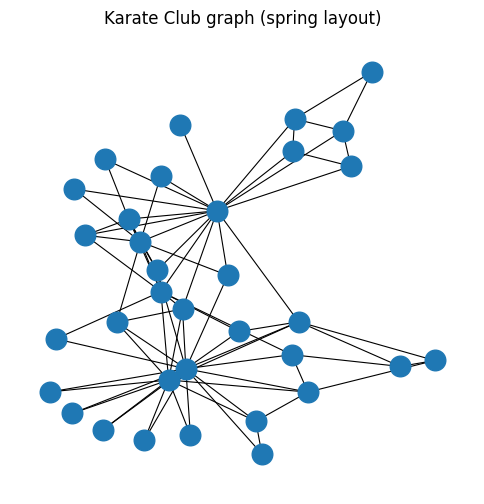

In [4]:
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos, node_size=220, with_labels=False, width=0.8)
plt.title('Karate Club graph (spring layout)')
plt.axis('off')
plt.show()